# Análisis Exploratorio de Datos (EDA) - Julio Encalada y Sara Cruz

## Proyecto

**Robot Educativo basado en Visión Artificial para apoyar la Comprensión Lectora en Educación General Básica**

**Estudiantes:** Julio Encalada y Sara Cruz  

**Modelo de visión artificial:** YOLOv8

In [2]:
# ==========================================================
# CELDA 1
# Instalación de librerías
# Proyecto: Robot Educativo
# Análisis Exploratorio de Datos (EDA)
# ==========================================================

!pip -q install roboflow
!pip -q install pandas
!pip -q install numpy
!pip -q install matplotlib
!pip -q install pillow
!pip -q install seaborn
!pip -q install scipy
!pip -q install pyyaml

print("Librerías instaladas correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.8 MB/s eta 0:00:00
Librerías instaladas correctamente.


In [3]:
#===========================================================
# CELDA 2
# Descarga automática del dataset
#
# Objetivo:
# Descargar desde Roboflow la versión oficial del dataset
# utilizado durante todo el proyecto experimental.
#
# Resultado esperado:
# Se crearán las carpetas:
#
# train/
# valid/
# test/
# data.yaml
#
#===========================================================

from roboflow import Roboflow
rf = Roboflow(api_key="tQF3ymHd1ARer4wUeiYU")
project = rf.workspace("julios-workspace-gq2sn").project("educabasica")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to EducaBasica-1 in yolov8:: 100%|██████████| 764/764 [00:00<00:00, 7779.64it/s]


In [4]:
# ==========================================================
# CELDA 3
# Importación de librerías
# ==========================================================

import os
import glob
import yaml
import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"]=(8,5)
plt.rcParams["figure.dpi"]=120

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [5]:
# ==========================================================
# CELDA 4
# Verificación del dataset descargado
# ==========================================================

DATASET_PATH = dataset.location

print("Ruta del dataset:")
print(DATASET_PATH)

print("\nContenido:")

for item in os.listdir(DATASET_PATH):
    print(item)

Ruta del dataset:
/content/EducaBasica-1

Contenido:
train
valid
test
data.yaml
README.roboflow.txt


In [6]:
# ==========================================================
# CELDA 5
# Construcción de la tabla maestra del dataset
# ==========================================================

import os
import yaml
import pandas as pd

# Leer archivo YAML
yaml_path = os.path.join(DATASET_PATH, "data.yaml")

with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

# Nombres de las clases
class_names = data_yaml["names"]

registros = []

# Recorrer train, valid y test
for subset in ["train", "valid", "test"]:

    label_dir = os.path.join(DATASET_PATH, subset, "labels")

    for archivo in os.listdir(label_dir):

        if archivo.endswith(".txt"):

            ruta = os.path.join(label_dir, archivo)

            with open(ruta, "r") as f:

                lineas = f.readlines()

                for linea in lineas:

                    valores = linea.strip().split()

                    if len(valores) != 5:
                        continue

                    clase = int(valores[0])

                    x = float(valores[1])
                    y = float(valores[2])
                    w = float(valores[3])
                    h = float(valores[4])

                    registros.append({

                        "subset": subset,
                        "imagen": archivo.replace(".txt",".jpg"),
                        "clase_id": clase,
                        "clase": class_names[clase],
                        "x_center": x,
                        "y_center": y,
                        "width": w,
                        "height": h,
                        "area_bbox": w*h,
                        "aspect_ratio": w/h if h>0 else None

                    })

# Crear DataFrame
df = pd.DataFrame(registros)

print("Número total de anotaciones:", len(df))

display(df.head())

Número total de anotaciones: 380


,subset,imagen,clase_id,clase,x_center,y_center,width,height,area_bbox,aspect_ratio
0,train,WhatsApp-Image-2026-07-13-at-10-36-40-PM-1-_jp...,2,panaderia,0.508594,0.552344,0.687500,0.570312,0.392090,1.205479
1,train,WhatsApp-Image-2026-07-12-at-1-35-09-PM-1-_jpe...,3,parque,0.491406,0.413281,0.703125,0.587500,0.413086,1.196809
2,train,WhatsApp-Image-2026-07-12-at-1-34-50-PM-5-_jpe...,4,supermercado,0.504687,0.475000,0.667188,0.557813,0.372166,1.196078
3,train,WhatsApp-Image-2026-07-12-at-1-35-05-PM-11-_jp...,3,parque,0.520312,0.507031,0.753125,0.590625,0.444814,1.275132
4,train,IMG_9634_jpeg.rf.7a73bdb10f27eaef3b814505b00dd...,1,hospital,0.610156,0.605469,0.779687,0.685937,0.534817,1.136674


In [7]:
# ==========================================================
# CELDA 6
# Resumen general del conjunto de datos
# ==========================================================

# Información general del dataset

total_imagenes = len(df)

num_clases = df["clase"].nunique()

clases = sorted(df["clase"].unique())

train = (df["subset"]=="train").sum()
valid = (df["subset"]=="valid").sum()
test = (df["subset"]=="test").sum()

resumen = pd.DataFrame({

    "Característica":[

        "Número total de anotaciones",
        "Número de clases",
        "Clases",
        "Entrenamiento",
        "Validación",
        "Prueba"

    ],

    "Valor":[

        total_imagenes,
        num_clases,
        ", ".join(clases),
        train,
        valid,
        test

    ]

})

display(resumen)

,Característica,Valor
0,Número total de anotaciones,380
1,Número de clases,5
2,Clases,"escuela, hospital, panaderia, parque, supermer..."
3,Entrenamiento,330
4,Validación,35
5,Prueba,15


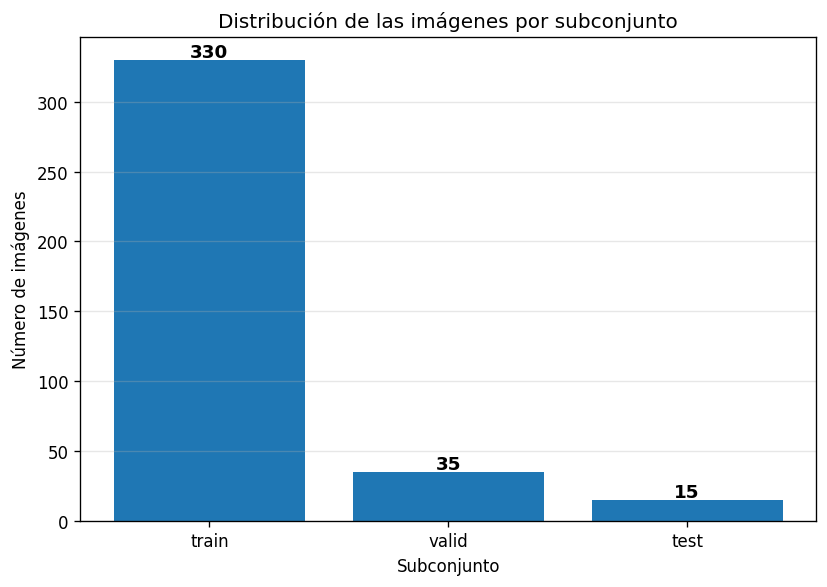

Figura guardada en:
Figuras_EDA/Figura1_Distribucion_Subconjuntos.png


In [8]:
# ==========================================================
# CELDA 7
# Figura 1
# Distribución de las imágenes por subconjunto
# ==========================================================

import os
import matplotlib.pyplot as plt

# Crear carpeta para guardar figuras
os.makedirs("Figuras_EDA", exist_ok=True)

# Conteo por subconjunto
subset_counts = df["subset"].value_counts().reindex(["train", "valid", "test"])

plt.figure(figsize=(7,5))

bars = plt.bar(
    subset_counts.index,
    subset_counts.values
)

# Mostrar valores sobre cada barra
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{int(bar.get_height())}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Distribución de las imágenes por subconjunto")
plt.xlabel("Subconjunto")
plt.ylabel("Número de imágenes")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figuras_EDA/Figura1_Distribucion_Subconjuntos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada en:")
print("Figuras_EDA/Figura1_Distribucion_Subconjuntos.png")

,Clase,Frecuencia,Porcentaje (%)
0,panaderia,76,20.0
1,parque,76,20.0
2,supermercado,76,20.0
3,hospital,76,20.0
4,escuela,76,20.0


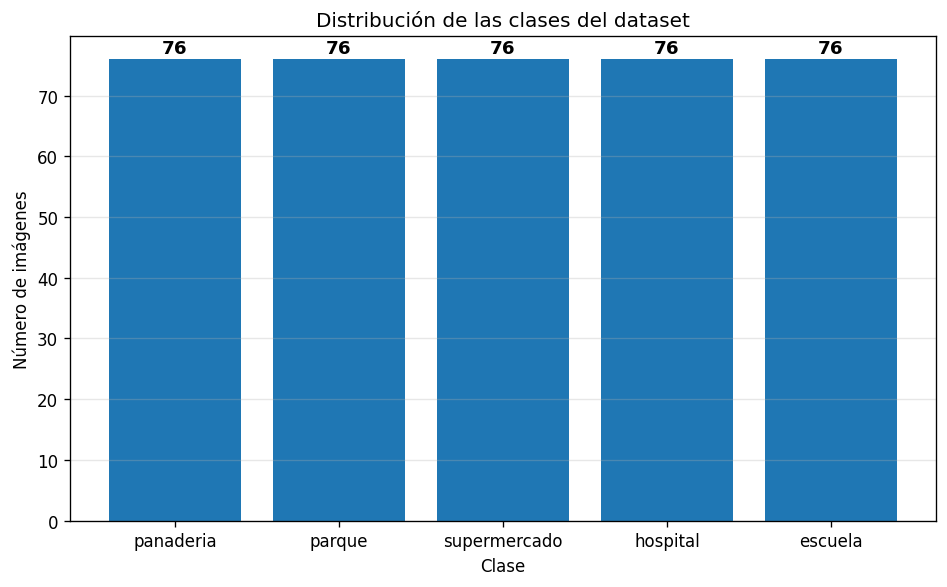

Figura guardada correctamente.


In [9]:
# ==========================================================
# CELDA 8
# Variables categóricas
# Frecuencia y porcentaje por clase
# ==========================================================

import matplotlib.pyplot as plt

# Frecuencia absoluta
frecuencia = df["clase"].value_counts()

# Porcentaje
porcentaje = round((frecuencia / frecuencia.sum()) * 100, 2)

tabla_clases = pd.DataFrame({
    "Clase": frecuencia.index,
    "Frecuencia": frecuencia.values,
    "Porcentaje (%)": porcentaje.values
})

display(tabla_clases)

# ---------------------------
# Figura
# ---------------------------

plt.figure(figsize=(8,5))

bars = plt.bar(
    tabla_clases["Clase"],
    tabla_clases["Frecuencia"]
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+1,
        str(int(bar.get_height())),
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Distribución de las clases del dataset")

plt.xlabel("Clase")

plt.ylabel("Número de imágenes")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figuras_EDA/Figura2_Distribucion_Clases.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada correctamente.")

In [10]:
# ==========================================================
# CELDA 9
# Estadísticas descriptivas
# ==========================================================

# Variables numéricas del dataset
variables = [
    "x_center",
    "y_center",
    "width",
    "height",
    "area_bbox",
    "aspect_ratio"
]

# Estadísticas descriptivas
estadisticas = (
    df[variables]
    .describe()
    .T[
        ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
    ]
    .round(4)
)

display(estadisticas)

# Guardar tabla
estadisticas.to_csv(
    "Figuras_EDA/Tabla5_Estadisticas_Descriptivas.csv"
)

print("Tabla guardada correctamente.")

,count,mean,std,min,25%,50%,75%,max
x_center,380.0,0.5400,0.0400,0.4586,0.5115,0.5332,0.5672,0.6453
y_center,380.0,0.5136,0.0556,0.3664,0.4836,0.5152,0.5531,0.6383
width,380.0,0.7387,0.0875,0.5516,0.6719,0.7328,0.7922,0.9766
height,380.0,0.7116,0.1555,0.4523,0.5773,0.6934,0.8344,1.0000
area_bbox,380.0,0.5339,0.1616,0.2495,0.3981,0.5201,0.6438,0.9598
aspect_ratio,380.0,1.0708,0.1755,0.6926,0.9013,1.1239,1.2308,1.3682


Tabla guardada correctamente.


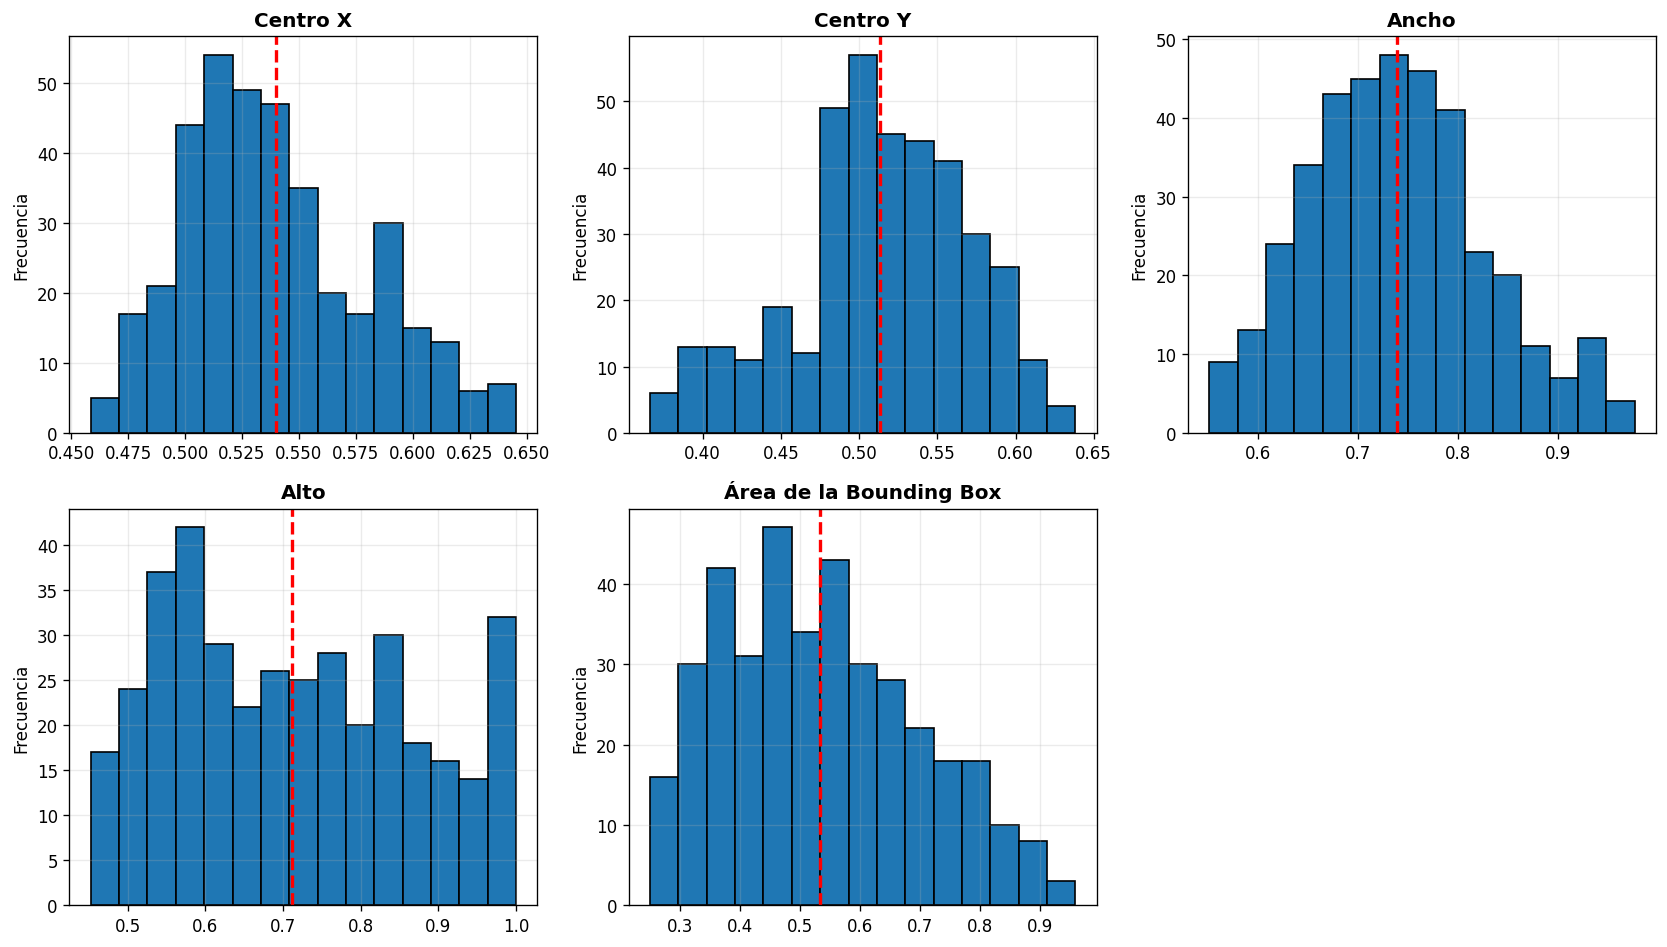

Figura 3 guardada correctamente.


In [11]:
# ==========================================================
# CELDA 10
# Figura 3
# Distribución de las variables numéricas
# ==========================================================

import matplotlib.pyplot as plt
import os

variables = [
    "x_center",
    "y_center",
    "width",
    "height",
    "area_bbox"
]

titulos = [
    "Centro X",
    "Centro Y",
    "Ancho",
    "Alto",
    "Área de la Bounding Box"
]

fig, axes = plt.subplots(2, 3, figsize=(14,8))
axes = axes.flatten()

for i, var in enumerate(variables):

    axes[i].hist(
        df[var],
        bins=15,
        edgecolor="black"
    )

    # Línea de la media
    axes[i].axvline(
        df[var].mean(),
        color="red",
        linestyle="--",
        linewidth=2
    )

    axes[i].set_title(titulos[i], fontsize=12, fontweight="bold")

    # Quitamos la etiqueta del eje X (es redundante)
    axes[i].set_xlabel("")

    axes[i].set_ylabel("Frecuencia")

    axes[i].grid(alpha=0.25)

# Eliminar el sexto panel vacío
fig.delaxes(axes[5])

plt.tight_layout()

os.makedirs("Figuras_EDA", exist_ok=True)

plt.savefig(
    "Figuras_EDA/Figura3_Distribuciones.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura 3 guardada correctamente.")

Matriz de correlación de Pearson:


,x_center,y_center,width,height,area_bbox,aspect_ratio
x_center,1.000,0.436,-0.031,0.357,0.234,-0.489
y_center,0.436,1.000,0.090,0.292,0.223,-0.340
width,-0.031,0.090,1.000,0.614,0.824,-0.132
height,0.357,0.292,0.614,1.000,0.948,-0.855
area_bbox,0.234,0.223,0.824,0.948,1.000,-0.653
aspect_ratio,-0.489,-0.340,-0.132,-0.855,-0.653,1.000


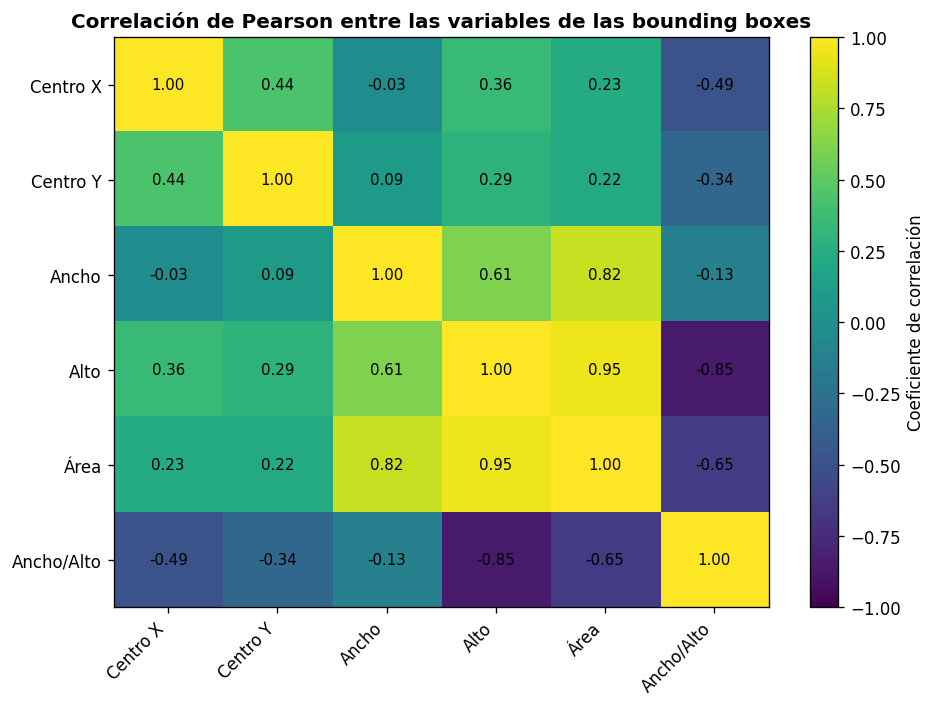

Figura 4 guardada correctamente en:
Figuras_EDA/Figura4_Correlacion_Pearson.png


In [12]:
# ==========================================================
# CELDA 11
# Tabla 6 y Figura 4
# Correlación de Pearson entre variables de las bounding boxes
# ==========================================================

import os
import matplotlib.pyplot as plt

# Variables numéricas de interés
variables = [
    "x_center",
    "y_center",
    "width",
    "height",
    "area_bbox",
    "aspect_ratio"
]

# Etiquetas para la figura
etiquetas = [
    "Centro X",
    "Centro Y",
    "Ancho",
    "Alto",
    "Área",
    "Ancho/Alto"
]

# Matriz de correlación de Pearson
corr = df[variables].corr(method="pearson")

print("Matriz de correlación de Pearson:")
display(corr.round(3))

# Crear figura
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    corr,
    interpolation="nearest",
    aspect="auto",
    vmin=-1,
    vmax=1
)

# Etiquetas de los ejes
ax.set_xticks(range(len(etiquetas)))
ax.set_xticklabels(
    etiquetas,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(etiquetas)))
ax.set_yticklabels(etiquetas)

# Valores dentro de cada celda
for i in range(len(corr)):
    for j in range(len(corr)):
        valor = corr.iloc[i, j]

        ax.text(
            j,
            i,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

ax.set_title(
    "Correlación de Pearson entre las variables de las bounding boxes",
    fontsize=12,
    fontweight="bold"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Coeficiente de correlación")

plt.tight_layout()

os.makedirs("Figuras_EDA", exist_ok=True)

plt.savefig(
    "Figuras_EDA/Figura4_Correlacion_Pearson.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura 4 guardada correctamente en:")
print("Figuras_EDA/Figura4_Correlacion_Pearson.png")

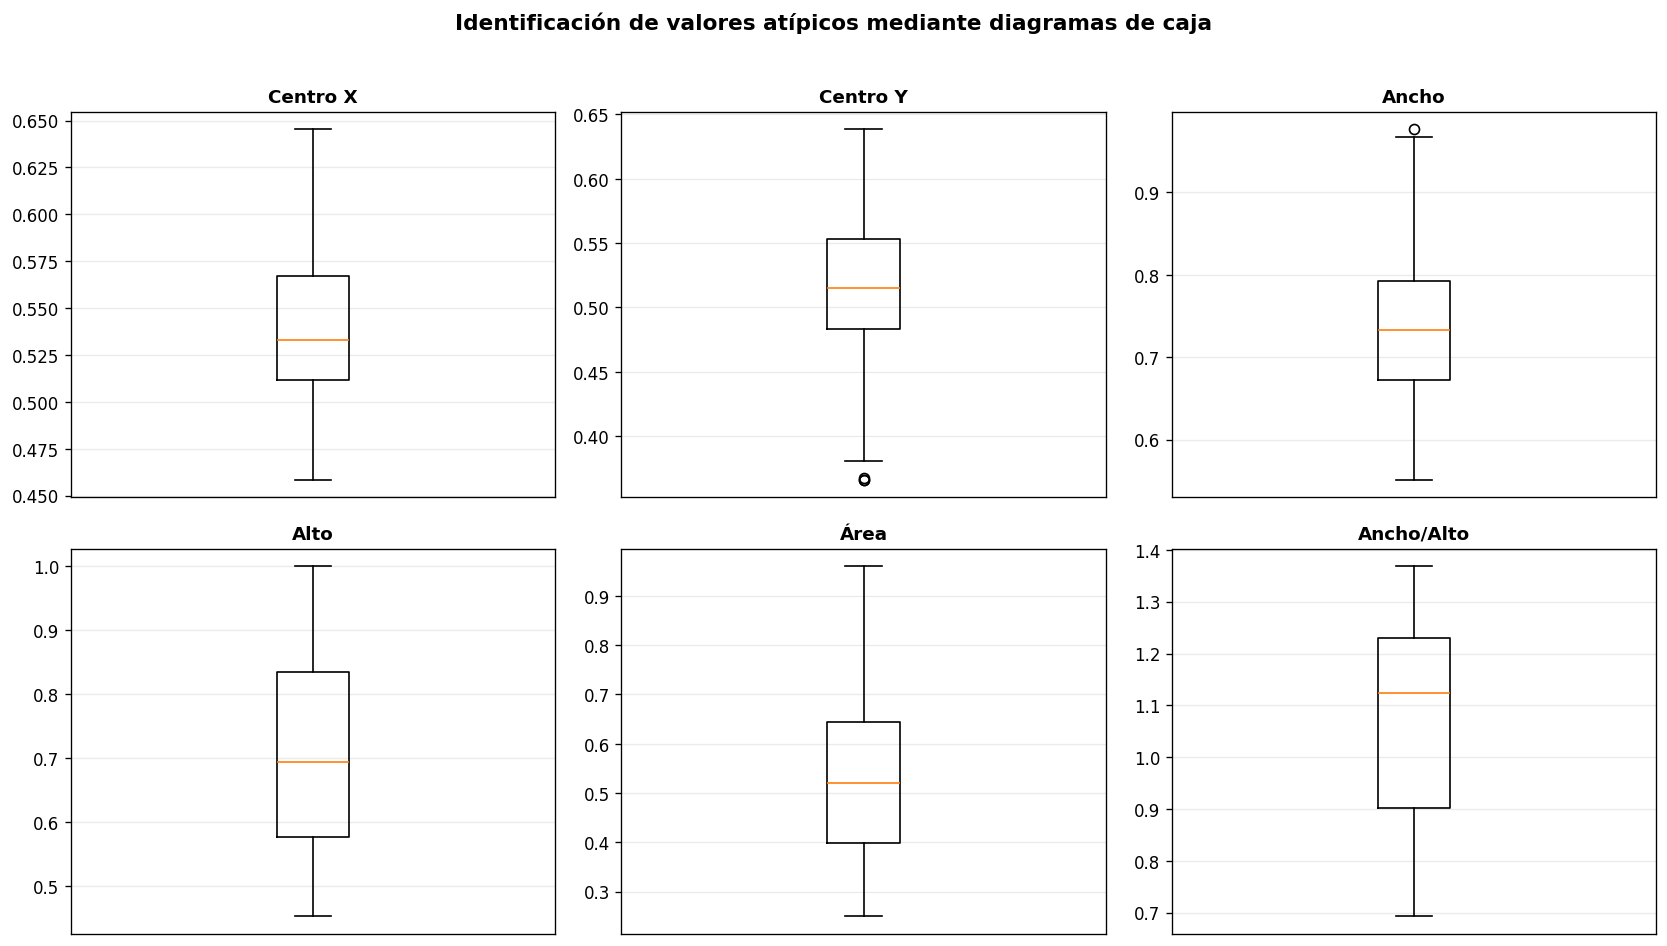

Tabla 7. Resumen de valores atípicos mediante el criterio IQR


,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Número de outliers,Decisión preliminar
0,Centro X,0.5115,0.5672,0.0557,0.4280,0.6507,0,No aplica
1,Centro Y,0.4836,0.5531,0.0695,0.3793,0.6574,3,Revisar y conservar si la anotación es correcta
2,Ancho,0.6719,0.7922,0.1203,0.4914,0.9727,1,Revisar y conservar si la anotación es correcta
3,Alto,0.5773,0.8344,0.2570,0.1918,1.2199,0,No aplica
4,Área,0.3981,0.6438,0.2457,0.0295,1.0124,0,No aplica
5,Ancho/Alto,0.9013,1.2308,0.3295,0.4070,1.7250,0,No aplica



Detalle de las muestras identificadas como valores atípicos:


,Variable,subset,imagen,clase,Valor atípico,Límite inferior,Límite superior
0,y_center,train,WhatsApp-Image-2026-07-12-at-1-35-10-PM_jpeg.r...,panaderia,0.366406,0.3793,0.6574
1,y_center,train,WhatsApp-Image-2026-07-12-at-1-35-10-PM_jpeg.r...,panaderia,0.366406,0.3793,0.6574
2,y_center,train,WhatsApp-Image-2026-07-12-at-1-35-10-PM_jpeg.r...,panaderia,0.367969,0.3793,0.6574
3,width,train,IMG_9802_jpeg.rf.0fdc67241ecb4f7f284632e7bbb45...,panaderia,0.976562,0.4914,0.9727



Archivos guardados:
Figuras_EDA/Figura5_Outliers_IQR.png
Figuras_EDA/Tabla7_Resumen_Outliers.csv
Figuras_EDA/Tabla7_Detalle_Outliers.csv


In [13]:
# ==========================================================
# CELDA 12
# Tabla 7 y Figura 5
# Identificación y detalle de valores atípicos mediante IQR
# ==========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# Variables numéricas analizadas
variables = [
    "x_center",
    "y_center",
    "width",
    "height",
    "area_bbox",
    "aspect_ratio"
]

# Etiquetas en español para la figura
etiquetas = [
    "Centro X",
    "Centro Y",
    "Ancho",
    "Alto",
    "Área",
    "Ancho/Alto"
]

resumen_outliers = []
detalle_outliers = []

# Crear figura
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(variables):

    # Cálculo del rango intercuartílico
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Identificación de outliers
    mascara_outliers = (
        (df[var] < limite_inferior) |
        (df[var] > limite_superior)
    )

    outliers_var = df.loc[
        mascara_outliers,
        [
            "subset",
            "imagen",
            "clase",
            var
        ]
    ].copy()

    # Agregar información detallada
    if not outliers_var.empty:
        outliers_var.insert(0, "Variable", var)
        outliers_var = outliers_var.rename(
            columns={var: "Valor atípico"}
        )

        outliers_var["Límite inferior"] = round(limite_inferior, 4)
        outliers_var["Límite superior"] = round(limite_superior, 4)

        detalle_outliers.append(outliers_var)

    # Resumen por variable
    resumen_outliers.append({
        "Variable": etiquetas[i],
        "Q1": round(q1, 4),
        "Q3": round(q3, 4),
        "IQR": round(iqr, 4),
        "Límite inferior": round(limite_inferior, 4),
        "Límite superior": round(limite_superior, 4),
        "Número de outliers": int(mascara_outliers.sum()),
        "Decisión preliminar": (
            "Revisar y conservar si la anotación es correcta"
            if mascara_outliers.sum() > 0
            else "No aplica"
        )
    })

    # Boxplot
    axes[i].boxplot(
        df[var].dropna(),
        vert=True,
        patch_artist=False
    )

    axes[i].set_title(
        etiquetas[i],
        fontsize=11,
        fontweight="bold"
    )

    axes[i].set_xticks([])
    axes[i].grid(axis="y", alpha=0.25)

fig.suptitle(
    "Identificación de valores atípicos mediante diagramas de caja",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

os.makedirs("Figuras_EDA", exist_ok=True)

plt.savefig(
    "Figuras_EDA/Figura5_Outliers_IQR.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ----------------------------------------------------------
# Tabla resumen
# ----------------------------------------------------------

tabla_outliers = pd.DataFrame(resumen_outliers)

print("Tabla 7. Resumen de valores atípicos mediante el criterio IQR")
display(tabla_outliers)

tabla_outliers.to_csv(
    "Figuras_EDA/Tabla7_Resumen_Outliers.csv",
    index=False,
    encoding="utf-8-sig"
)

# ----------------------------------------------------------
# Tabla con el detalle exacto de los outliers
# ----------------------------------------------------------

if detalle_outliers:

    tabla_detalle_outliers = pd.concat(
        detalle_outliers,
        ignore_index=True
    )

    print("\nDetalle de las muestras identificadas como valores atípicos:")
    display(tabla_detalle_outliers)

    tabla_detalle_outliers.to_csv(
        "Figuras_EDA/Tabla7_Detalle_Outliers.csv",
        index=False,
        encoding="utf-8-sig"
    )

else:

    tabla_detalle_outliers = pd.DataFrame()

    print("\nNo se identificaron valores atípicos mediante el criterio IQR.")

print("\nArchivos guardados:")
print("Figuras_EDA/Figura5_Outliers_IQR.png")
print("Figuras_EDA/Tabla7_Resumen_Outliers.csv")

if not tabla_detalle_outliers.empty:
    print("Figuras_EDA/Tabla7_Detalle_Outliers.csv")

In [14]:
# ==========================================================
# CELDA 13
# Tabla 8
# Verificación final de la integridad del dataset
# ==========================================================

import pandas as pd

# --------------------------------------------
# Valores nulos
# --------------------------------------------
valores_nulos = int(df.isnull().sum().sum())

# --------------------------------------------
# Registros duplicados
# --------------------------------------------
duplicados = int(df.duplicated().sum())

# --------------------------------------------
# Coordenadas fuera del rango permitido por YOLO
# --------------------------------------------
variables_yolo = [
    "x_center",
    "y_center",
    "width",
    "height"
]

fuera_rango = 0

for var in variables_yolo:

    fuera_rango += int(
        ((df[var] < 0) | (df[var] > 1)).sum()
    )

# --------------------------------------------
# Clases sin muestras
# --------------------------------------------
clases_sin_muestras = int(
    (df["clase"].value_counts() == 0).sum()
)

# --------------------------------------------
# Bounding boxes con dimensiones inválidas
# --------------------------------------------
dimensiones_invalidas = int(
    ((df["width"] <= 0) | (df["height"] <= 0)).sum()
)

# --------------------------------------------
# Tabla resumen
# --------------------------------------------

tabla_calidad = pd.DataFrame({

    "Verificación":[

        "Valores nulos",
        "Registros duplicados",
        "Coordenadas fuera del rango [0,1]",
        "Bounding boxes con dimensiones inválidas",
        "Clases sin muestras"

    ],

    "Resultado":[

        valores_nulos,
        duplicados,
        fuera_rango,
        dimensiones_invalidas,
        clases_sin_muestras

    ],

    "Estado":[

        "Correcto" if valores_nulos==0 else "Revisar",
        "Correcto" if duplicados==0 else "Revisar",
        "Correcto" if fuera_rango==0 else "Revisar",
        "Correcto" if dimensiones_invalidas==0 else "Revisar",
        "Correcto" if clases_sin_muestras==0 else "Revisar"

    ]

})

print("Tabla 8. Verificación final de la calidad del dataset")

display(tabla_calidad)

# Guardar

tabla_calidad.to_csv(
    "Figuras_EDA/Tabla8_Verificacion_Final.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nTabla guardada correctamente.")
print("Figuras_EDA/Tabla8_Verificacion_Final.csv")

Tabla 8. Verificación final de la calidad del dataset


,Verificación,Resultado,Estado
0,Valores nulos,0,Correcto
1,Registros duplicados,0,Correcto
2,"Coordenadas fuera del rango [0,1]",0,Correcto
3,Bounding boxes con dimensiones inválidas,0,Correcto
4,Clases sin muestras,0,Correcto



Tabla guardada correctamente.
Figuras_EDA/Tabla8_Verificacion_Final.csv
